In [1]:
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.signal import spectrogram
from scipy.ndimage import gaussian_filter1d
from scipy.signal import convolve
from scipy.signal import find_peaks
import random
from scipy.signal import savgol_filter

In [2]:
CONTEXT = 10

class Pipeline:

    d = None
    
    x_diff = None
    y_diff = None

    x_mask = None
    y_mask = None
    mask= None

    saccade_signals = None
    saccade_gen = None
    saccade_seq = None
    
    
    def __init__(self, t, x, y, x_left, y_left):
        self.t = t
        self.x = x
        self.y = y
        self.x_left = x_left
        self.y_left = y_left

    def run(self):
        
        (
        self.t,
        self.x,
        self.y,
        self.x_left,
        self.y_left
        ) = self.__drop_nans_with_context(self.t, self.x, self.y, self.x_left, self.y_left, context_size=5)
        
        self.t = self.__normalization_min_max_positive(self.t)
        self.x = self.__normalization_min_max(self.x)
        self.y = self.__normalization_min_max(self.y)
        self.x_left = self.__normalization_min_max(self.x_left)
        self.y_left = self.__normalization_min_max(self.y_left)

        self.d = self.__calculate_distance(self.x, self.y)
        
        self.__calculate_diff()
        
        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)
        
        self.x_diff = self.__strech_signal(self.x_diff)
        self.y_diff = self.__strech_signal(self.y_diff)
        
        self.x_diff = self.__highpass_filtering(self.x_diff)
        self.y_diff = self.__highpass_filtering(self.y_diff)
        
        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)
        
        self.x_diff = self.__smooth_signal(self.x_diff)
        self.y_diff = self.__smooth_signal(self.y_diff)

        self.x_diff = self.__highligth_peaks(self.x_diff)
        self.y_diff = self.__highligth_peaks(self.y_diff)

        self.x_diff = abs(self.x_diff)
        self.y_diff = abs(self.y_diff)

        self.x_diff = self.__lowpass_filtering(self.x_diff)
        self.y_diff = self.__lowpass_filtering(self.y_diff)
        
        self.x_diff = abs(self.x_diff)
        self.y_diff = abs(self.y_diff)

        self.x_diff = self.__zero_outliers(self.x_diff)
        self.y_diff = self.__zero_outliers(self.y_diff)

        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)

        self.x_diff = self.__strech_signal(self.x_diff)
        self.y_diff = self.__strech_signal(self.y_diff)

        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)

        self.x_mask = self.__detect_peaks(self.x_diff, prominence=0.05, distance=10)
        self.y_mask = self.__detect_peaks(self.y_diff, prominence=0.05, distance=10)

        # self.__plot_results()

        self.d = self.__normalization_min_max_positive(self.d)
        # self.d = self.__savgol_filter(self.d)
        # print(self.d.isna().sum())
        # self.mask = self.__idt(self.x, self.y, self.t)
        self.mask = self.__contextual_dot_product(self.x_mask, self.y_mask, context=10)

        self.x = self.__normalization_min_max_positive(self.x)
        self.y = self.__normalization_min_max_positive(self.x)
        self.x_left = self.__normalization_min_max_positive(self.x)
        self.y_left = self.__normalization_min_max_positive(self.x)
        
        x_saccade = self.__extract_peak_segments(self.x, self.mask, context_size=CONTEXT)
        y_saccade = self.__extract_peak_segments(self.y, self.mask, context_size=CONTEXT)
        x_left_saccade = self.__extract_peak_segments(self.x_left, self.mask, context_size=CONTEXT)
        y_left_saccade = self.__extract_peak_segments(self.y_left, self.mask, context_size=CONTEXT)
        # for signal in self.saccade_signals:
        #     nans = np.sum(np.isnan(signal))
        #     if nans != 0:
        #         print(nans)

        # self.saccade_gen = self.__generate_smoothed_signal(self.saccade_signals)

        # self.saccade_seq = next(self.saccade_gen)

        # self.saccade_seq = self.__highpass_filtering(self.saccade_seq)

        # self.saccade_seq = self.__normalization_min_max(self.saccade_seq)
        
        return x_saccade, y_saccade, x_left_saccade, y_left_saccade

    def __drop_nans_with_context(self, *signals, context_size=10):
        assert len(signals) > 0, "At least one signal must be provided."
    
        signals = [pd.Series(sig).reset_index(drop=True) if not isinstance(sig, pd.Series) else sig.reset_index(drop=True) for sig in signals]
        nan_indices = np.unique(np.concatenate([
            sig[sig.isna() | (sig == "nan")].index for sig in signals
        ]))
    
        if len(nan_indices) == 0:
            return signals

        expanded_indices = np.unique(np.concatenate([
            np.arange(max(0, idx - context_size), min(len(signals[0]), idx + context_size + 1))
            for idx in nan_indices
        ]))
    
        filtered_signals = [sig.drop(expanded_indices).reset_index(drop=True) for sig in signals]
    
        filtered_signals = [sig.dropna().reset_index(drop=True) for sig in filtered_signals]
    
        min_length = min(map(len, filtered_signals))
        filtered_signals = [sig.iloc[:min_length].reset_index(drop=True) for sig in filtered_signals]
    
        return tuple(filtered_signals)

    def __calculate_distance(self, x, y):
        return np.sqrt(np.power(x, 2) + np.power(y, 2))
        
    def __calculate_diff(self):
        self.x_diff = abs(self.x - self.x_left)
        self.y_diff = abs(self.y - self.y_left)

    def __normalization_min_max_positive(self, signal):
        return (signal - signal.min()) / (signal.max() - signal.min())

    def __normalization_min_max(self, signal):
        return 2*((signal - signal.min()) / (signal.max() - signal.min())) - 1

    def __strech_signal(self, signal):
        power = 2
        mean = signal.mean()
        
        signal = np.power(signal, power)
        signal = signal / signal.mean() * mean

        return signal

    def __highpass_filtering(self, signal):
        def highpass_filter(data, cutoff=len(self.t) / 1e1, fs=1/np.mean(np.diff(self.t)), order=4):
            nyquist = 0.5 * fs  # Nyquist frequency
            normal_cutoff = cutoff / nyquist  # Normalize cutoff frequency
            b, a = butter(order, normal_cutoff, btype='high', analog=False)  # Change to 'high'
            return filtfilt(b, a, data)

        return highpass_filter(signal)

    def __smooth_signal(self, signal, sigma=5):
        return gaussian_filter1d(signal, sigma=sigma)

    def __highligth_peaks(self,signal):
        difference_kernel = np.array([-1,-1, 0, 1,1]) 
        return convolve(signal, difference_kernel, mode="same")

    def __lowpass_filtering(self, signal):
        def lowpass_filter(data, cutoff=len(self.t) / 1e1, fs=1/np.mean(np.diff(self.t)), order=4):
            nyquist = 0.5 * fs  # Nyquist frequency
            normal_cutoff = cutoff / nyquist  # Normalize cutoff frequency
            b, a = butter(order, normal_cutoff, btype='low', analog=False)
            return filtfilt(b, a, data)

        return lowpass_filter(signal)

    def __zero_outliers(self, signal):
        Q1 = np.percentile(signal, 5) 
        Q3 = np.percentile(signal, 95)
        IQR = Q3 - Q1
        
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        filtered_signal = signal.copy()
        filtered_signal[(filtered_signal < lower) | (filtered_signal > upper)] = 0
    
        return filtered_signal

    def __detect_peaks(self, signal, height=None, prominence=0.1, distance=5):
        signal = np.array(signal)
        peaks, _ = find_peaks(signal, height=height, prominence=prominence, distance=distance)
        peak_mask = np.zeros(len(signal), dtype=int)
        peak_mask[peaks] = 1
        
        return peak_mask

    def __plot_results(self):

        start = 32498
        end = start + 200
        
        fig, axes = plt.subplots(6, 1, figsize=(8, 8), sharex=True)
        
        axes[0].plot(self.t.iloc[start:end], self.x.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[0].set_ylabel("X Position Rigth Eye")
        axes[0].set_title("X vs Time")
        axes[0].grid(True)
        
        axes[1].plot(self.t.iloc[start:end], self.x_left.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[1].set_xlabel("Time (Normalized)")
        axes[1].set_ylabel("X Position Left Eye")
        axes[1].set_title("X vs Time")
        axes[1].grid(True)
        
        axes[2].plot(self.t.iloc[start:end], self.x_mask[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[2].set_xlabel("Time (Normalized)")
        axes[2].set_ylabel("X Diffrence")
        axes[2].set_title("saccade movement")
        axes[2].grid(True)

        axes[3].plot(self.t.iloc[start:end], self.y.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[3].set_ylabel("X Position Rigth Eye")
        axes[3].set_title("Y vs Time")
        axes[3].grid(True)
        
        axes[4].plot(self.t.iloc[start:end], self.y_left.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[4].set_xlabel("Time (Normalized)")
        axes[4].set_ylabel("X Position Left Eye")
        axes[4].set_title("Y vs Time")
        axes[4].grid(True)
        
        axes[5].plot(self.t.iloc[start:end], self.y_mask[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[5].set_xlabel("Time (Normalized)")
        axes[5].set_ylabel("X Diffrence")
        axes[5].set_title("saccade movement")
        axes[5].grid(True)
        
        plt.tight_layout()
        plt.show()

    def __extract_peak_segments(self, signal, mask, context_size=5):
        signal = np.array(signal)
        mask = np.array(mask)
    
        assert len(signal) == len(mask), "Signal and mask must have the same length."
    
        extracted_segments = []
        peak_indices = np.where(mask == 1)[0]
    
        for idx in peak_indices:
            start = max(0, idx - context_size)
            end = min(len(signal), idx + context_size + 1)
            
            extracted_segments.append(signal[start:end])
        return extracted_segments

    def __generate_smoothed_signal(self, fragments):
        if not fragments:
            return
        random.shuffle(fragments)
        smoothed_signal = [fragments[0]]
    
        last_value = fragments[0][-1]
    
        for i in range(1, len(fragments)):
            shift = last_value - fragments[i][0]
            translated_fragment = fragments[i] + shift
    
            smoothed_signal.append(translated_fragment)
            last_value = translated_fragment[-1]

        yield np.concatenate(smoothed_signal)

    def __savgol_filter(self, signal):
        return savgol_filter(signal, window_length=11, polyorder=3)
    
    def __idt(self, x, y, t, velocity_threshold=30):
        dx = np.diff(x)
        dy = np.diff(y)
        dt = np.diff(t)
    
        velocity = np.sqrt(dx**2 + dy**2) / dt  
        velocity = np.insert(velocity, 0, 0)
    
        saccade_mask = velocity > velocity_threshold
        saccade_mask = saccade_mask.astype(int)
    
        return saccade_mask
    
    def __contextual_dot_product(self, signal1, signal2, context):
        assert len(signal1) == len(signal2), "Signals must be of equal length"
    
        # Create a kernel with ones in the given context range
        kernel = np.ones(2 * context + 1)
    
        # Convolve signal2 with the kernel (this spreads 1s over the context)
        spread_signal2 = convolve(signal2, kernel, mode='same')  # 'same' keeps original size
    
        # Convert convolved signal to binary (any nonzero value means a 1 was nearby)
        spread_signal2 = (spread_signal2 > 0).astype(int)
    
        # Perform element-wise AND (dot product-like)
        result = signal1 * spread_signal2
        return result
    




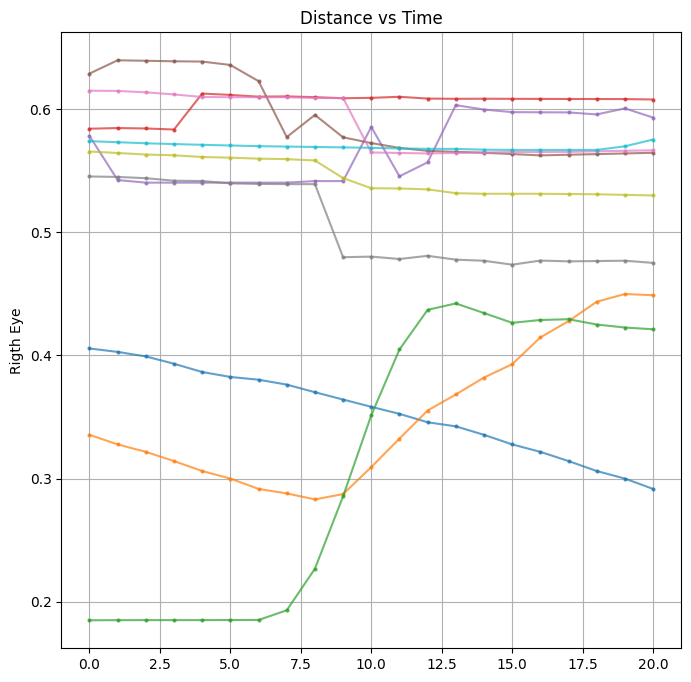

In [3]:
file_path = "../data/00/data.csv"
df = pd.read_csv(file_path)

selected_columns = ["t", "right_gaze_origin_position_in_hmd_coordinates_x", "right_gaze_origin_position_in_hmd_coordinates_y",
                    "left_gaze_origin_position_in_hmd_coordinates_x", "left_gaze_origin_position_in_hmd_coordinates_y"]
df = df[selected_columns]

df = df.rename(columns={
    "right_gaze_origin_position_in_hmd_coordinates_x": "x",
    "right_gaze_origin_position_in_hmd_coordinates_y": "y",
    "left_gaze_origin_position_in_hmd_coordinates_x": "x_left",
    "left_gaze_origin_position_in_hmd_coordinates_y": "y_left"
})

pipeline = Pipeline(df["t"], df["x"], df["y"], df["x_left"], df["y_left"])
saccade_signals = pipeline.run()

fig, axes = plt.subplots(1, 1, figsize=(8, 8), sharex=True)

for signal in saccade_signals[3][:10]:
    axes.plot(signal, marker='o', linestyle='-', markersize=2, alpha=0.7)
axes.set_ylabel("Rigth Eye")
axes.set_title("Distance vs Time")
axes.grid(True)

# print(len(saccade_seq))

In [4]:
labels_num = 2

In [5]:
import pandas as pd

# Selected columns to read from each CSV file
selected_columns = [
    "t", "right_gaze_origin_position_in_hmd_coordinates_x", "right_gaze_origin_position_in_hmd_coordinates_y",
    "left_gaze_origin_position_in_hmd_coordinates_x", "left_gaze_origin_position_in_hmd_coordinates_y"
]

# Renaming dictionary (base names)
rename_dict = {
    "t": "t", 
    "right_gaze_origin_position_in_hmd_coordinates_x": "x",
    "right_gaze_origin_position_in_hmd_coordinates_y": "y",
    "left_gaze_origin_position_in_hmd_coordinates_x": "x_left",
    "left_gaze_origin_position_in_hmd_coordinates_y": "y_left"
}

# List to store all DataFrames
df_list = []

# Load each CSV file and process it
for i in range(labels_num):  # Loop from 00 to 09
    file_path = f"../data/{i:02d}/data.csv"  # Format path dynamically
    
    # Load CSV, only select needed columns
    df = pd.read_csv(file_path, usecols=selected_columns)
    
    # Trim to 100,000 rows
    df = df.iloc[:100000]
    
    # Rename columns with appropriate suffix
    df = df.rename(columns={col: f"{rename_dict[col]}{i:02d}" for col in selected_columns})
    
    # Append processed DataFrame to the list
    df_list.append(df)

# Concatenate all DataFrames side-by-side
merged_df = pd.concat(df_list, axis=1)

merged_df.head()


,t00,x00,y00,x_left00,y_left00,t01,x01,y01,x_left01,y_left01
0,1.581362e+15,-29.585846,1.740021,32.436142,5.695251,1.583335e+15,-33.649307,0.915329,29.914169,4.788696
1,1.581362e+15,-29.591797,1.740555,32.421951,5.614624,1.583335e+15,-33.651520,0.925964,29.914185,4.745239
2,1.581362e+15,-29.599228,1.711990,32.406448,5.580765,1.583335e+15,-33.654449,0.910370,29.913483,4.757553
3,1.581362e+15,-29.606445,1.710693,32.386810,5.647583,1.583335e+15,-33.655487,0.906570,29.913757,4.726425
4,1.581362e+15,-29.615341,1.769791,32.370270,5.730347,1.583335e+15,-33.656067,0.902786,29.921448,4.677521


In [6]:
import pandas as pd
import numpy as np

# List of signal types to extract
signal_types = ["t", "x", "y", "x_left", "y_left"]

# Create an empty list to store instances
instances = []

# Iterate over the 10 labels (00 to 09)
for i in range(labels_num):  
    label = i  # Assign label from 0 to 9
    
    for signal_type in signal_types:  # Iterate over all signal types
        signal = merged_df[f"{signal_type}{i:02d}"]  # Extract the correct column
        
        # Split the signal into 10 segments of 10,000 each
        for j in range(10):
            segment = signal[j * 10000 : (j + 1) * 10000].values  # Extract 10,000-length segment
            
            # Create a row with label, signal type, segment number, and signal values
            instance = [label, signal_type, j + 1] + list(segment)  # j+1 to start segments from 1
            
            # Store instance
            instances.append(instance)

# Define column names
columns = ["label", "signal_type", "segment"] + [f"dim_{i}" for i in range(10000)]

# Convert list to DataFrame
df_processed = pd.DataFrame(instances, columns=columns)

df_processed.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_9990,dim_9991,dim_9992,dim_9993,dim_9994,dim_9995,dim_9996,dim_9997,dim_9998,dim_9999
0,0,t,1,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
1,0,t,2,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
2,0,t,3,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
3,0,t,4,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
4,0,t,5,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15


In [7]:
df_train_raw = df_processed[df_processed["segment"].between(1, 6)]
df_val_raw = df_processed[df_processed["segment"].between(7,8)]
df_test_raw = df_processed[df_processed["segment"].between(9, 10)]

In [8]:
df_train_raw.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_9990,dim_9991,dim_9992,dim_9993,dim_9994,dim_9995,dim_9996,dim_9997,dim_9998,dim_9999
0,0,t,1,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
1,0,t,2,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
2,0,t,3,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
3,0,t,4,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
4,0,t,5,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15


In [9]:
df_test_raw.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_9990,dim_9991,dim_9992,dim_9993,dim_9994,dim_9995,dim_9996,dim_9997,dim_9998,dim_9999
8,0,t,9,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
9,0,t,10,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
18,0,x,9,-2.990927e+01,-2.998026e+01,-3.002446e+01,-3.001945e+01,-3.001668e+01,-3.001811e+01,-3.003775e+01,...,-3.049767e+01,-3.049767e+01,-3.049767e+01,-3.049771e+01,-3.049779e+01,-3.049789e+01,-3.048491e+01,-3.037790e+01,-3.016847e+01,-2.997070e+01
19,0,x,10,-2.991096e+01,-2.991100e+01,-2.993440e+01,-2.994386e+01,-2.993948e+01,-2.993697e+01,-2.993445e+01,...,-3.110291e+01,-3.115651e+01,-3.117418e+01,-3.118117e+01,-3.120784e+01,-3.121338e+01,-3.121408e+01,-3.121478e+01,-3.121684e+01,-3.121889e+01
28,0,y,9,4.440231e+00,4.467010e+00,4.447861e+00,4.524704e+00,4.523743e+00,4.494003e+00,4.359497e+00,...,3.703949e+00,3.703949e+00,3.703949e+00,3.702026e+00,3.701538e+00,3.701096e+00,3.720657e+00,3.821564e+00,3.790878e+00,3.927002e+00


In [10]:
df_val_raw.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_9990,dim_9991,dim_9992,dim_9993,dim_9994,dim_9995,dim_9996,dim_9997,dim_9998,dim_9999
6,0,t,7,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
7,0,t,8,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
16,0,x,7,-2.964194e+01,-2.963448e+01,-2.966989e+01,-2.967346e+01,-2.967860e+01,-2.967662e+01,-2.967274e+01,...,-2.988069e+01,-2.988994e+01,-2.988834e+01,-2.988745e+01,-2.988666e+01,-2.988661e+01,-2.988655e+01,-2.988615e+01,-2.988655e+01,-2.988634e+01
17,0,x,8,-2.988655e+01,-2.988634e+01,-2.988655e+01,-2.988661e+01,-2.988666e+01,-2.988678e+01,-2.988690e+01,...,-2.988496e+01,-2.988054e+01,-2.987500e+01,-2.988220e+01,-2.986838e+01,-2.987280e+01,-2.985788e+01,-2.986806e+01,-2.986948e+01,-2.987563e+01
26,0,y,7,4.521317e+00,4.422272e+00,4.166809e+00,4.100616e+00,4.008209e+00,4.072952e+00,4.102341e+00,...,3.152298e+00,3.182236e+00,3.212982e+00,3.208160e+00,3.212982e+00,3.213165e+00,3.213364e+00,3.213715e+00,3.214081e+00,3.214233e+00


# features generation

(10000,)
-30.45625305175781
Generated signal: [0.6635789  0.66341645 0.66339479 0.66334425 0.66324317 0.6631818
 0.66312043 0.66288578 0.6624995  0.66243452 0.66237676 0.66200854
 0.66147065 0.6613804  0.66042013 0.65984253 0.65919273 0.65890032
 0.65827578 0.65762959 0.65757905]


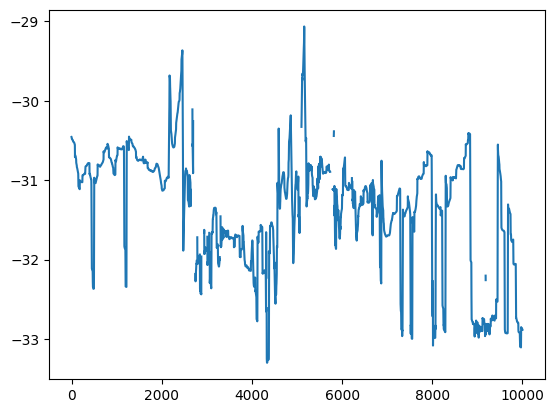

In [11]:
# Select a specific label and segment
label = df_train_raw["label"].unique()[1]  # Select the first label
segment = df_train_raw[df_train_raw["label"] == label]["segment"].unique()[2]  # Select the first segment for that label

# Filter the dataframe for the selected label and segment
df_segment = df_train_raw[(df_train_raw["label"] == label) & (df_train_raw["segment"] == segment)]

# Extract input signals based on signal_type
t = df_segment[df_segment["signal_type"] == "t"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
x = df_segment[df_segment["signal_type"] == "x"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
y = df_segment[df_segment["signal_type"] == "y"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
x_left = df_segment[df_segment["signal_type"] == "x_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
y_left = df_segment[df_segment["signal_type"] == "y_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()

plt.plot(x)
print(x.shape)
print(x[0])
# Run the pipeline
pipeline = Pipeline(t, x, y, x_left, y_left)
x_saccade, y_saccade, x_left_saccade, y_left_saccade = pipeline.run()

# Print the result
print("Generated signal:", x_saccade[0])


In [12]:
def generate_features(df):
    generated_signals = []
    generated_labels = []
    
    # Iterate over unique labels
    for label in df["label"].unique():
        df_label = df[df["label"] == label]
    
        # Iterate over unique segments
        for segment in df_label["segment"].unique():
            df_segment = df_label[df_label["segment"] == segment]
    
            # Extract input signals for the pipeline based on signal_type
            t = df_segment[df_segment["signal_type"] == "t"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            x = df_segment[df_segment["signal_type"] == "x"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            y = df_segment[df_segment["signal_type"] == "y"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            x_left = df_segment[df_segment["signal_type"] == "x_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            y_left = df_segment[df_segment["signal_type"] == "y_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
    
            # Run the pipeline 10 times for each segment
            # for _ in range(10):
            pipeline = Pipeline(t, x, y, x_left, y_left)
            results = pipeline.run()
            
            # Store the generated signal and label
            for result in results:
                generated_signals.extend(result)
                generated_labels.extend([label]*len(result))
    
    # Convert results into DataFrame
    return pd.DataFrame(generated_signals), pd.DataFrame({"label": generated_labels})

df_train, df_train_labels = generate_features(df_train_raw)
# df_train = df_train.iloc[:, :1000]

df_test, df_test_labels = generate_features(df_test_raw)
# df_test = df_test.iloc[:, :1000]

df_val, df_val_labels = generate_features(df_val_raw)
# df_val = df_val.iloc[:, :1000]

In [13]:
df_train.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,0.302920,0.299089,0.294058,0.285899,0.276683,0.271181,0.268110,0.262633,0.254174,0.246001,...,0.230069,0.220660,0.216129,0.206667,0.195998,0.187714,0.177431,0.166323,0.157928,0.146381
1,0.216129,0.206667,0.195998,0.187714,0.177431,0.166323,0.157928,0.146381,0.141378,0.134733,...,0.170704,0.202468,0.233786,0.251646,0.270549,0.285363,0.315267,0.333367,0.355008,0.363620
2,0.289609,0.289384,0.289220,0.289145,0.289091,0.288970,0.288930,0.288930,0.286370,0.274066,...,0.220932,0.192370,0.179791,0.164677,0.148809,0.143778,0.153743,0.156957,0.162188,0.162113
3,0.306109,0.304859,0.302342,0.300196,0.303623,0.315689,0.336262,0.359839,0.379813,0.379381,...,0.385601,0.384484,0.385001,0.384209,0.383341,0.380320,0.382845,0.382113,0.385144,0.381970
4,0.363535,0.363495,0.363360,0.363224,0.363210,0.363192,0.363060,0.353444,0.319070,0.259923,...,0.124879,0.066663,0.025562,0.009569,0.004910,0.007598,0.006559,0.004374,0.003349,0.002978


In [14]:
df_train = df_train.fillna(df_train.mean())
df_test = df_test.fillna(df_test.mean())
df_val = df_val.fillna(df_val.mean())

In [15]:
df_train.isna().sum().sum()

np.int64(0)

In [16]:
df_train_labels.head()

,label
0,0
1,0
2,0
3,0
4,0


In [17]:
df_test.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,0.423005,0.421821,0.421996,0.422524,0.422807,0.423748,0.423774,0.423855,0.424190,0.423923,...,0.423416,0.422504,0.421498,0.421039,0.421485,0.421251,0.420873,0.420349,0.419864,0.420082
1,0.660368,0.663281,0.658743,0.653493,0.653395,0.654912,0.653395,0.651640,0.652223,0.650752,...,0.651754,0.651800,0.651846,0.651930,0.651846,0.651800,0.651754,0.651234,0.650713,0.650228
2,0.143908,0.143214,0.142394,0.143214,0.142394,0.143214,0.143908,0.144598,0.146102,0.174478,...,0.273037,0.593642,0.595445,0.591956,0.591734,0.589449,0.591585,0.585683,0.585585,0.583808
3,0.467726,0.468165,0.468706,0.468846,0.468982,0.469044,0.470737,0.473084,0.473572,0.473751,...,0.473751,0.473680,0.473139,0.468566,0.468507,0.588196,0.589104,0.588196,0.585992,0.583792
4,0.473139,0.468566,0.468507,0.588196,0.589104,0.588196,0.585992,0.583792,0.579316,0.574840,...,0.573248,0.572763,0.572278,0.571542,0.572278,0.572278,0.572278,0.570956,0.570810,0.569338


In [18]:
df_test_labels.head()

,label
0,0
1,0
2,0
3,0
4,0


In [19]:
# shuffled_indices = df_train.sample(frac=1, random_state=42).index

# df_train = df_train.loc[shuffled_indices].reset_index(drop=True)
# df_train_labels = df_train_labels.loc[shuffled_indices].reset_index(drop=True)

# shuffled_indices = df_test.sample(frac=1, random_state=42).index

# df_test = df_test.loc[shuffled_indices].reset_index(drop=True)
# df_test_labels = df_test_labels.loc[shuffled_indices].reset_index(drop=True)

# shuffled_indices = df_val.sample(frac=1, random_state=42).index

# df_val = df_val.loc[shuffled_indices].reset_index(drop=True)
# df_val_labels = df_val_labels.loc[shuffled_indices].reset_index(drop=True)

In [20]:
def shuffle_dataframe_grouped(df, df_labels, group_size=4, random_state=42):
    # Step 1: Compute group indices (every 4 rows are one group)
    num_groups = len(df) // group_size
    group_indices = np.arange(num_groups)

    # Step 2: Shuffle group indices
    np.random.seed(random_state)
    np.random.shuffle(group_indices)

    # Step 3: Reconstruct dataframe and labels in shuffled order
    shuffled_df = pd.concat([df.iloc[i * group_size : (i + 1) * group_size] for i in group_indices]).reset_index(drop=True)
    shuffled_labels = pd.concat([df_labels.iloc[i * group_size : (i + 1) * group_size] for i in group_indices]).reset_index(drop=True)

    return shuffled_df, shuffled_labels

# Apply to train, test, and validation sets
df_train, df_train_labels = shuffle_dataframe_grouped(df_train, df_train_labels, group_size=4)
df_test, df_test_labels = shuffle_dataframe_grouped(df_test, df_test_labels, group_size=4)
df_val, df_val_labels = shuffle_dataframe_grouped(df_val, df_val_labels, group_size=4)

# Machine Learning

## Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [22]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Ensure num_rows is a multiple of 4
assert df_train.shape[0] % 4 == 0, "Number of rows in df_train is not a multiple of 4!"
assert df_test.shape[0] % 4 == 0, "Number of rows in df_test is not a multiple of 4!"

# Convert DataFrames to NumPy arrays
X_train = df_train.values
X_test = df_test.values
y_train = df_train_labels["label"].values
y_test = df_test_labels["label"].values

# Get original feature count per row
num_features_per_row = X_train.shape[1]  # Each row has `num_features_per_row` features

# Reshape: Group every 4 rows into a single sample
X_train_reshaped = X_train.reshape(-1, num_features_per_row * 4)  # (num_samples, num_features)
X_test_reshaped = X_test.reshape(-1, num_features_per_row * 4)  # (num_samples, num_features)

# Adjust Labels: Keep only every 4th label (assuming labels are duplicated for each row in a group)
y_train_reshaped = y_train[::4]
y_test_reshaped = y_test[::4]

# Verify Shapes
print(f"X_train_reshaped shape: {X_train_reshaped.shape}")  # Expected: (num_samples, num_features_per_sample)
print(f"y_train_reshaped shape: {y_train_reshaped.shape}")  # Expected: (num_samples,)

# Train Random Forest Model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_reshaped, y_train_reshaped)

# Predict
y_pred = clf.predict(X_test_reshaped)

# Evaluate Performance
accuracy = accuracy_score(y_test_reshaped, y_pred)
report = classification_report(y_test_reshaped, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)


X_train_reshaped shape: (257, 84)
y_train_reshaped shape: (257,)
Test Accuracy: 0.6486
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.47      0.52        30
           1       0.68      0.77      0.72        44

    accuracy                           0.65        74
   macro avg       0.63      0.62      0.62        74
weighted avg       0.64      0.65      0.64        74



as expected classical machine learning algorithms are failing

## Deep Learning

In [23]:
import torch
import numpy as np
import random

def set_seed(seed=0):
    torch.manual_seed(seed)  # Sets PyTorch seed (CPU)
    torch.cuda.manual_seed(seed)  # Sets PyTorch seed (GPU)
    torch.cuda.manual_seed_all(seed)  # If using multi-GPU
    np.random.seed(seed)  # Sets NumPy seed
    random.seed(seed)  # Sets Python random seed

    torch.backends.cudnn.deterministic = True  # Ensures deterministic behavior
    torch.backends.cudnn.benchmark = False  # Disables cuDNN optimization for reproducibility

set_seed(0)  # Set seed to 0

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
# # CNN + LSTM
# class NN(nn.Module):
#     def __init__(self, num_classes):
#         super(NN, self).__init__()

#         # 1D Convolutional Layers (Feature Extraction)
#         self.conv1 = nn.Conv1d(in_channels=1, out_channels=2048, kernel_size=16, stride=1, padding=2)
#         self.bn1 = nn.BatchNorm1d(2048)

#         self.conv2 = nn.Conv1d(2048, 1024, kernel_size=8, stride=1, padding=2)
#         self.bn2 = nn.BatchNorm1d(1024)

#         self.conv3 = nn.Conv1d(1024, 512, kernel_size=4, stride=1, padding=2)
#         self.bn3 = nn.BatchNorm1d(512)

#         self.conv4 = nn.Conv1d(512, 256, kernel_size=2, stride=1, padding=1)
#         self.bn4 = nn.BatchNorm1d(256)

#         self.pool = nn.MaxPool1d(kernel_size=4, stride=2)
#         self.dropout1 = nn.Dropout(0.3)
#         self.dropout2 = nn.Dropout(0.05)

#         # LSTM Layers (Temporal Dependencies)
#         self.lstm = nn.LSTM(input_size=256, hidden_size=128, num_layers=2, batch_first=True, bidirectional=True)
        
#         # Fully Connected Layers
#         self.fc1 = nn.Linear(256, 128)  # 2x128 because of bidirectional LSTM
#         self.fc2 = nn.Linear(128, num_classes)
        
#     def forward(self, x):
#         # CNN Feature Extraction
#         x = self.pool(nn.ReLU()(self.bn1(self.conv1(x))))
#         x = self.pool(nn.ReLU()(self.bn2(self.conv2(x))))
#         x = self.pool(nn.ReLU()(self.bn3(self.conv3(x))))
#         x = self.pool(nn.ReLU()(self.bn4(self.conv4(x))))
        
#         x = self.dropout1(x)  # Apply dropout
        
#         # Prepare for LSTM (batch_size, seq_length, features)
#         x = x.permute(0, 2, 1)  # Swap to (batch_size, seq_len, channels)
        
#         # LSTM Processing
#         x, _ = self.lstm(x)

#         # Take the last time-step's output
#         x = x[:, -1, :]
#         x = self.dropout2(x)
#         # Fully Connected Layers
#         x = nn.ReLU()(self.fc1(x))
        
#         x = self.fc2(x)

#         return x

# # CNN
# class NN(nn.Module):
#     def __init__(self, num_classes):
#         super(NN, self).__init__()

#         self.conv1 = nn.Conv1d(in_channels=1, out_channels=2048, kernel_size=16, stride=1, padding=2)
#         self.bn1 = nn.BatchNorm1d(2048)

#         self.conv2 = nn.Conv1d(2048, 1024, kernel_size=8, stride=1, padding=2)
#         self.bn2 = nn.BatchNorm1d(1024)

#         self.conv3 = nn.Conv1d(1024, 512, kernel_size=8, stride=1, padding=2)
#         self.bn3 = nn.BatchNorm1d(512)

#         self.conv4 = nn.Conv1d(512, 256, kernel_size=4, stride=1, padding=2)
#         self.bn4 = nn.BatchNorm1d(256)

#         self.conv5 = nn.Conv1d(256, 256, kernel_size=4, stride=1, padding=2)
#         self.bn5 = nn.BatchNorm1d(256)

#         self.conv6 = nn.Conv1d(256, 256, kernel_size=2, stride=1, padding=1)
#         self.bn6 = nn.BatchNorm1d(256)

#         # Pooling and Dropout Layers
#         self.pool = nn.MaxPool1d(kernel_size=4, stride=2)
#         self.dropout1 = nn.Dropout(0.3)
#         self.dropout2 = nn.Dropout(0.4)

#         # Adaptive Pooling to keep FC layer input size fixed
#         self.global_pool = nn.AdaptiveAvgPool1d(1)

#         # Fully Connected Layers
#         self.fc1 = nn.Linear(256, 128)
#         self.fc2 = nn.Linear(128, num_classes)

#     def forward(self, x):
#         x = self.pool(nn.ReLU()(self.bn1(self.conv1(x))))
#         x = self.pool(nn.ReLU()(self.bn2(self.conv2(x))))
#         x = self.pool(nn.ReLU()(self.bn3(self.conv3(x))))
#         x = self.pool(nn.ReLU()(self.bn4(self.conv4(x))))
#         x = self.pool(nn.ReLU()(self.bn5(self.conv5(x))))
#         x = self.pool(nn.ReLU()(self.bn6(self.conv6(x))))

#         x = self.global_pool(x)  # Output: (batch_size, 1024, 1)
#         x = x.view(x.size(0), -1)  # Flatten: (batch_size, 1024)

#         x = nn.ReLU()(self.fc1(x))
#         x = self.dropout1(x)
#         x = self.fc2(x)
#         # self.dropout2(x)
        
#         return x

# mini CNN

# neurons = [256,512,1024,2048]
neurons = [2048,1024,512,256]

class NN(nn.Module):
    def __init__(self, num_classes):
        super(NN, self).__init__()

        self.conv1 = nn.Conv1d(in_channels=4, out_channels=neurons[0], kernel_size=8, stride=1, padding=2)
        self.bn1 = nn.BatchNorm1d(neurons[0])

        self.conv2 = nn.Conv1d(neurons[0], neurons[1], kernel_size=4, stride=1, padding=2)
        self.bn2 = nn.BatchNorm1d(neurons[1])

        self.conv3 = nn.Conv1d(neurons[1], neurons[2], kernel_size=4, stride=1, padding=2)
        self.bn3 = nn.BatchNorm1d(neurons[2])
        
        # Pooling and Dropout Layers
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout(0.3)
        # self.dropout2 = nn.Dropout(0.4)

        # Adaptive Pooling to keep FC layer input size fixed
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # Fully Connected Layers
        self.fc1 = nn.Linear(neurons[2], neurons[3])
        self.fc2 = nn.Linear(neurons[3], num_classes)

    def forward(self, x):
        x = nn.ReLU()(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = nn.ReLU()(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = nn.ReLU()(self.bn3(self.conv3(x)))
        x = self.pool(x)
        
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        # x = x.squeeze(-1)

        x = nn.ReLU()(self.fc1(x))
        x = self.dropout1(x)
        x = self.fc2(x)
        # self.dropout2(x)
        
        return x


# # mini CNN + LSTM
# class NN(nn.Module):
#     def __init__(self, num_classes):
#         super(NN, self).__init__()

#         # 1D Convolutional Layers (Feature Extraction)
#         self.conv1 = nn.Conv1d(in_channels=1, out_channels=256, kernel_size=4, stride=1, padding=2)
#         self.bn1 = nn.BatchNorm1d(256)

#         self.conv2 = nn.Conv1d(256, 128, kernel_size=2, stride=1, padding=2)
#         self.bn2 = nn.BatchNorm1d(128)

#         self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
#         self.dropout1 = nn.Dropout(0.3)
#         self.dropout2 = nn.Dropout(0.05)

#         # LSTM Layers (Temporal Dependencies)
#         self.lstm = nn.LSTM(input_size=128, hidden_size=64, num_layers=2, batch_first=True, bidirectional=True)
        
#         # Fully Connected Layers
#         self.fc1 = nn.Linear(128, 64)  # 2x128 because of bidirectional LSTM
#         self.fc2 = nn.Linear(64, num_classes)
        
#     def forward(self, x):
#         # CNN Feature Extraction
#         x = self.pool(nn.ReLU()(self.bn1(self.conv1(x))))
#         x = self.pool(nn.ReLU()(self.bn2(self.conv2(x))))
        
#         # x = self.dropout1(x)  # Apply dropout
        
#         # Prepare for LSTM (batch_size, seq_length, features)
#         x = x.permute(0, 2, 1)  # Swap to (batch_size, seq_len, channels)
        
#         # LSTM Processing
#         x, _ = self.lstm(x)

#         # Take the last time-step's output
#         x = x[:, -1, :]
#         # x = self.dropout2(x)
#         # Fully Connected Layers
#         x = nn.ReLU()(self.fc1(x))
        
#         x = self.fc2(x)

#         return x




Epoch 1/10, Loss: 6.0545, Accuracy: 55.25%
Epoch 2/10, Loss: 5.2232, Accuracy: 65.76%
Epoch 3/10, Loss: 4.6593, Accuracy: 74.71%
Epoch 4/10, Loss: 4.3560, Accuracy: 77.82%
Epoch 5/10, Loss: 4.0769, Accuracy: 78.99%
Epoch 6/10, Loss: 3.6685, Accuracy: 83.27%
Epoch 7/10, Loss: 4.5767, Accuracy: 84.82%
Epoch 8/10, Loss: 3.5031, Accuracy: 85.60%
Epoch 9/10, Loss: 3.8520, Accuracy: 80.93%
Epoch 10/10, Loss: 3.3672, Accuracy: 84.05%
Test Accuracy: 45.95%

Classification Report:
               precision    recall  f1-score   support

           0       0.31      0.27      0.29        30
           1       0.54      0.59      0.57        44

    accuracy                           0.46        74
   macro avg       0.42      0.43      0.43        74
weighted avg       0.45      0.46      0.45        74



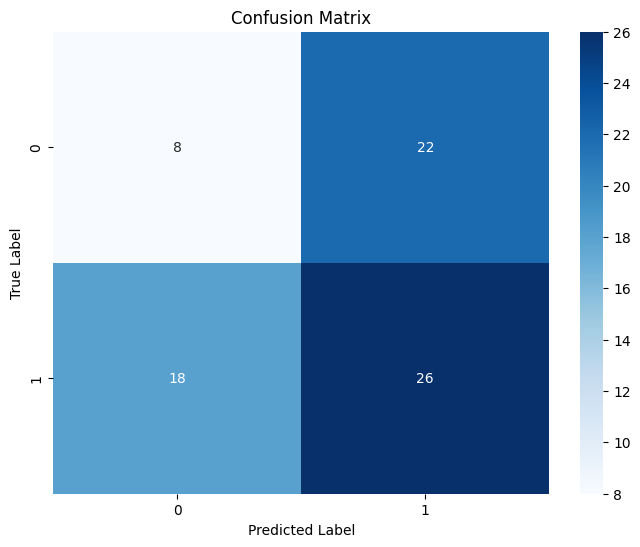

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader

X_train = df_train.values.astype(np.float32)
y_train = df_train_labels["label"].values[::4].astype(np.int64)

X_val = df_val.values.astype(np.float32)
y_val = df_val_labels["label"].values[::4].astype(np.int64)

X_test = df_test.values.astype(np.float32)
y_test = df_test_labels["label"].values[::4].astype(np.int64)

# ✅ Ensure correct shape: (num_samples, 4 features, sequence_length)
sequence_length = 2 * CONTEXT + 1  # Each sample consists of `sequence_length` timestamps
num_features = 4  # 4 Features per timestamp

X_train = X_train.reshape(-1, num_features, sequence_length)  # ✅ Now shape is (num_samples, 4, sequence_length)
X_val = X_val.reshape(-1, num_features, sequence_length)
X_test = X_test.reshape(-1, num_features, sequence_length)


# Define PyTorch Dataset
class SignalDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)  # No unsqueeze(1), we now have multiple features per timestamp
        self.y = torch.tensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create Dataloaders
train_dataset = SignalDataset(X_train, y_train)
test_dataset = SignalDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Initialize Model
num_classes = len(np.unique(y_train))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize Model
model = NN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training Loop
def train_model(model, train_loader, num_epochs=10):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct, total = 0, 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
        
        accuracy = 100 * correct / total
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss:.4f}, Accuracy: {accuracy:.2f}%")

# Train Model
train_model(model, train_loader, num_epochs=10)

# Function to evaluate model and display confusion matrix
def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    
    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

    # Compute Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("\nClassification Report:\n", classification_report(all_labels, all_preds))

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Test the model and show confusion matrix
evaluate_model(model, test_loader)


Epoch 1, Loss: 6.1350, Accuracy: 50.19%, Val Accuracy: 27.27%
Epoch 2, Loss: 5.5036, Accuracy: 71.60%, Val Accuracy: 45.45%
Epoch 3, Loss: 5.1113, Accuracy: 74.71%, Val Accuracy: 63.64%
Epoch 4, Loss: 5.1625, Accuracy: 75.88%, Val Accuracy: 60.61%
Epoch 5, Loss: 4.8423, Accuracy: 79.77%, Val Accuracy: 66.67%
Epoch 6, Loss: 4.4278, Accuracy: 78.60%, Val Accuracy: 63.64%
Epoch 7, Loss: 4.5652, Accuracy: 80.16%, Val Accuracy: 66.67%
Epoch 8, Loss: 4.6240, Accuracy: 83.27%, Val Accuracy: 63.64%
Epoch 9, Loss: 4.3323, Accuracy: 81.32%, Val Accuracy: 66.67%
Epoch 10, Loss: 4.3232, Accuracy: 85.21%, Val Accuracy: 66.67%

Training Stopped! Best Validation Accuracy: 66.67%


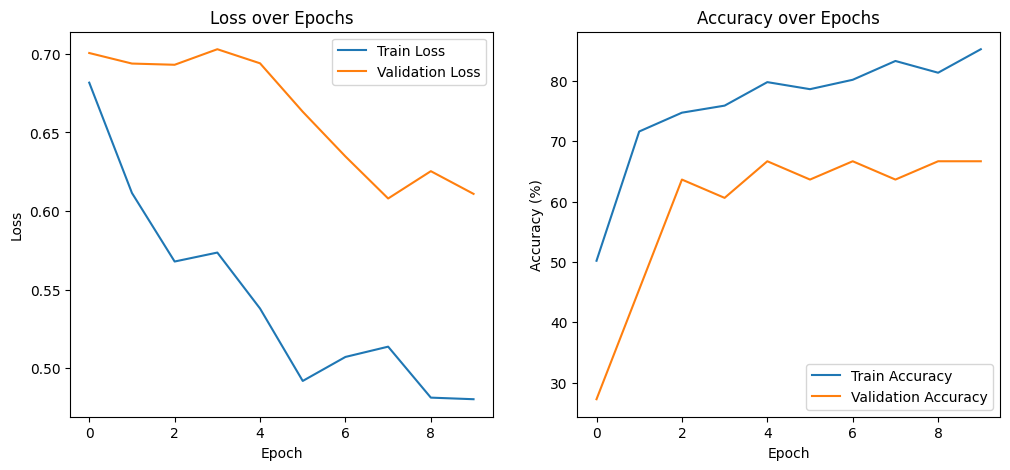

Test Accuracy: 50.00%

Classification Report:
               precision    recall  f1-score   support

           0       0.36      0.30      0.33        30
           1       0.57      0.64      0.60        44

    accuracy                           0.50        74
   macro avg       0.47      0.47      0.46        74
weighted avg       0.49      0.50      0.49        74



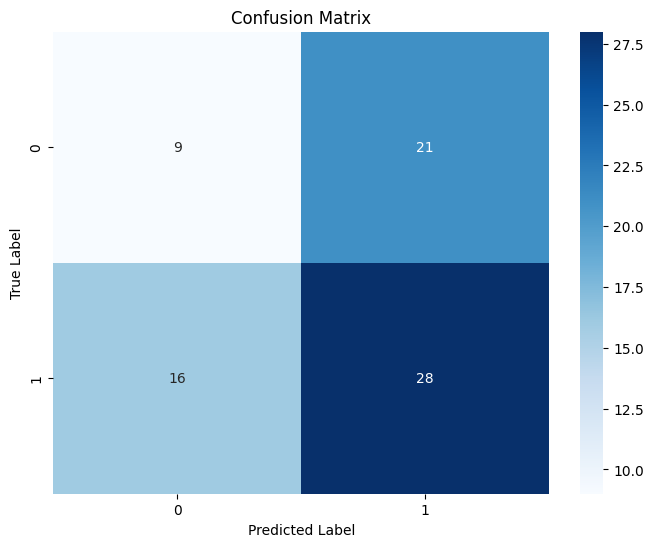

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader

X_train = df_train.values.astype(np.float32)
y_train = df_train_labels["label"].values[::4].astype(np.int64)

X_val = df_val.values.astype(np.float32)
y_val = df_val_labels["label"].values[::4].astype(np.int64)

X_test = df_test.values.astype(np.float32)
y_test = df_test_labels["label"].values[::4].astype(np.int64)

# ✅ Ensure correct shape: (num_samples, 4 features, sequence_length)
sequence_length = 2 * CONTEXT + 1  # Each sample consists of `sequence_length` timestamps
num_features = 4  # 4 Features per timestamp

X_train = X_train.reshape(-1, num_features, sequence_length)  # ✅ Now shape is (num_samples, 4, sequence_length)
X_val = X_val.reshape(-1, num_features, sequence_length)
X_test = X_test.reshape(-1, num_features, sequence_length)


# Define PyTorch Dataset
class SignalDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create Dataloaders
train_dataset = SignalDataset(X_train, y_train)
val_dataset = SignalDataset(X_val, y_val)
test_dataset = SignalDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Initialize Model
num_classes = len(np.unique(y_train))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.00001) # 0.0001

# Training Function with Early Stopping
def train_model(model, train_loader, val_loader, patience=5):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_val_acc = 0
    patience_counter = 0

    epoch = 0
    while patience_counter < patience:  # Stop if no improvement in `patience` epochs
        epoch += 1
        model.train()
        running_loss = 0.0
        correct, total = 0, 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
        
        train_acc = 100 * correct / total
        train_losses.append(running_loss / len(train_loader))
        train_accuracies.append(train_acc)

        # Validation Step
        model.eval()
        val_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == y_batch).sum().item()
                total += y_batch.size(0)
        
        val_acc = 100 * correct / total
        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(val_acc)

        # Print Epoch Summary
        print(f"Epoch {epoch}, Loss: {running_loss:.4f}, Accuracy: {train_acc:.2f}%, Val Accuracy: {val_acc:.2f}%")

        # Early Stopping Logic
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0  # Reset patience counter
            torch.save(model.state_dict(), "best_model.pth")  # Save best model
        else:
            patience_counter += 1  # Increase patience counter if no improvement

    print(f"\nTraining Stopped! Best Validation Accuracy: {best_val_acc:.2f}%")

    # Load best model
    model.load_state_dict(torch.load("best_model.pth"))

    # Plot Training & Validation Loss/Accuracy
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss over Epochs")

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train Accuracy")
    plt.plot(val_accuracies, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.title("Accuracy over Epochs")

    plt.show()

# Train Model with Early Stopping
train_model(model, train_loader, val_loader, patience=5)

# Function to Evaluate Model on Test Data
def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    
    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

    # Compute Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("\nClassification Report:\n", classification_report(all_labels, all_preds))

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Evaluate Model on Test Data
evaluate_model(model, test_loader)


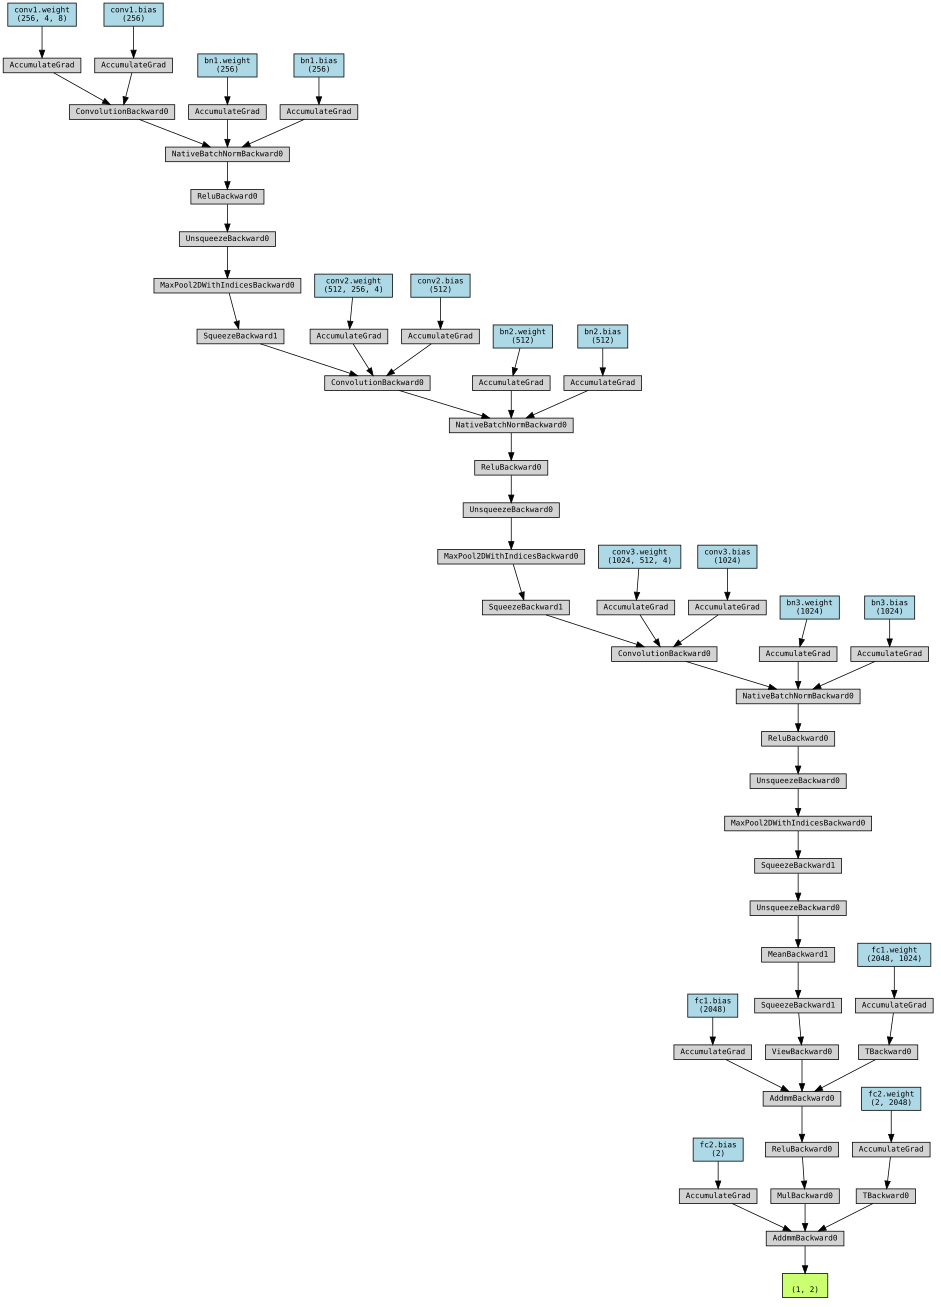

In [28]:
from torchviz import make_dot

# Create a dummy input
dummy_input = torch.randn(1, 4, 1000)  # Batch size 1, 1 channel, sequence length 1000
model = NN(labels_num)

# Forward pass
output = model(dummy_input)

# Create visualization
dot = make_dot(output, params=dict(model.named_parameters()))
dot.render("model_architecture", format="png")  # Save to file
dot  # Display in Jupyter Notebook


In [29]:
# mini LSTM + CNN
class NN(nn.Module):
    def __init__(self, num_classes):
        super(NN, self).__init__()

        # LSTM Layers (Processes 1 feature per timestep, sequence length = 21)
        self.lstm = nn.LSTM(input_size=4, hidden_size=64, num_layers=2, batch_first=True, bidirectional=True)

        # 1D Convolutional Layers (Feature Extraction After LSTM)
        self.conv1 = nn.Conv1d(in_channels=128, out_channels=64, kernel_size=4, stride=1, padding=1)
        self.bn1 = nn.BatchNorm1d(64)

        self.conv2 = nn.Conv1d(64, 32, kernel_size=2, stride=1, padding=1)
        self.bn2 = nn.BatchNorm1d(32)

        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.3)

        # **Calculate correct input size for FC layer**
        self.fc1_input_size = 32 * ((CONTEXT * 2 + 1) // (2 * 2))  # 21 shrinks by two pool layers
        self.fc1 = nn.Linear(self.fc1_input_size, 64)
        self.fc2 = nn.Linear(64, num_classes)
        
    def forward(self, x):
        # LSTM Processing: (batch_size, sequence_length=21, features=1) -> (batch_size, sequence_length=21, 128)
        x, _ = self.lstm(x)

        # Prepare for CNN: (batch_size, sequence_length, 128) -> (batch_size, 128, sequence_length)
        x = x.permute(0, 2, 1)  # Swap to (batch_size, channels, sequence_length)

        # CNN Feature Extraction
        x = self.pool(nn.ReLU()(self.bn1(self.conv1(x))))
        x = self.pool(nn.ReLU()(self.bn2(self.conv2(x))))
        
        # x = self.dropout(x)  # Apply dropout
        
        # Flatten before FC layers
        x = x.view(x.size(0), -1)  # Flatten
        
        # Fully Connected Layers
        x = nn.ReLU()(self.fc1(x))
        # x = self.dropout(x)
        x = self.fc2(x)

        return x

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader

X_train = df_train.values.astype(np.float32)
y_train = df_train_labels["label"].values.astype(np.int64)

X_val = df_val.values.astype(np.float32)
y_val = df_val_labels["label"].values.astype(np.int64)

X_test = df_test.values.astype(np.float32)
y_test = df_test_labels["label"].values.astype(np.int64)

# ✅ Ensure correct shape: (num_samples, 4 features, sequence_length)
sequence_length = 2 * CONTEXT + 1  # Each sample consists of `sequence_length` timestamps
num_features = 4  # 4 Features per timestamp

X_train = X_train.reshape(-1, num_features, sequence_length)  # ✅ Now shape is (num_samples, 4, sequence_length)
X_val = X_val.reshape(-1, num_features, sequence_length)
X_test = X_test.reshape(-1, num_features, sequence_length)


# Define PyTorch Dataset
# Define PyTorch Dataset
class SignalDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X).float()  # Convert to Tensor
        self.y = torch.tensor(y).long()   # Ensure labels are LongTensor
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx].unsqueeze(-1), self.y[idx]  # (sequence_length, 1)


# Create Dataloaders
train_dataset = SignalDataset(X_train, y_train)
val_dataset = SignalDataset(X_val, y_val)
test_dataset = SignalDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Checking training data for NaN or Inf:")
print("NaNs in X_train:", np.isnan(X_train).sum())
print("Infs in X_train:", np.isinf(X_train).sum())

print("Max value:", np.max(X_train))
print("Min value:", np.min(X_train))


# Initialize Model
num_classes = len(np.unique(y_train))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training Function with Early Stopping
def train_model(model, train_loader, val_loader, patience=5):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_val_acc = 0
    patience_counter = 0

    epoch = 0
    while patience_counter < patience:  # Stop if no improvement in `patience` epochs
        epoch += 1
        model.train()
        running_loss = 0.0
        correct, total = 0, 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
        
        train_acc = 100 * correct / total
        train_losses.append(running_loss / len(train_loader))
        train_accuracies.append(train_acc)

        # Validation Step
        model.eval()
        val_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == y_batch).sum().item()
                total += y_batch.size(0)
        
        val_acc = 100 * correct / total
        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(val_acc)

        # Print Epoch Summary
        print(f"Epoch {epoch}, Loss: {running_loss:.4f}, Accuracy: {train_acc:.2f}%, Val Accuracy: {val_acc:.2f}%")

        # Early Stopping Logic
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0  # Reset patience counter
            torch.save(model.state_dict(), "best_model.pth")  # Save best model
        else:
            patience_counter += 1  # Increase patience counter if no improvement

    print(f"\nTraining Stopped! Best Validation Accuracy: {best_val_acc:.2f}%")

    # Load best model
    model.load_state_dict(torch.load("best_model.pth"))

    # Plot Training & Validation Loss/Accuracy
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss over Epochs")

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train Accuracy")
    plt.plot(val_accuracies, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.title("Accuracy over Epochs")

    plt.show()

# Train Model with Early Stopping
train_model(model, train_loader, val_loader, patience=5)

# Function to Evaluate Model on Test Data
def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    
    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

    # Compute Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("\nClassification Report:\n", classification_report(all_labels, all_preds))

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Evaluate Model on Test Data
evaluate_model(model, test_loader)


Checking training data for NaN or Inf:
NaNs in X_train: 0
Infs in X_train: 0
Max value: 1.0
Min value: 0.0


ValueError: LSTM: Expected input to be 2D or 3D, got 4D instead